# Fuzzy Logic Evaluation of Loading Fuel Ratio

Notebook ini mengevaluasi **Loading** dengan Mamdani Fuzzy Logic. Fuel consumption dipilih dari referensi OEM yang paling cocok dengan `unit_type`; jika tidak ada kecocokan, notebook memakai median referensi aktivitas dan menandainya sebagai fallback.

Penting: output fuzzy adalah **Fuel Ratio Risk Score** relatif (`0–1`), bukan pengganti Fuel Ratio aktual. Fuel Ratio aktual hanya disebut aktual jika berasal dari `loading_summary`; bila transaksi belum ada, notebook menampilkan estimasi berbasis referensi OEM.

In [1]:
from pathlib import Path
import re
import sqlite3
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzzy
from skfuzzy import control as ctrl

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 11

def find_database():
    candidates = [Path.cwd() / 'frms.db', Path.cwd() / 'backend' / 'frms.db']
    if '__file__' in globals():
        candidates.insert(0, Path(__file__).resolve().parent / 'frms.db')
    for candidate in candidates:
        if candidate.exists() and candidate.stat().st_size > 0:
            return candidate.resolve()
    raise FileNotFoundError('frms.db tidak ditemukan. Jalankan notebook dari project root atau backend/.')

db_path = find_database()
print(f'✅ Database: {db_path}')

✅ Database: /Users/rifkinasss/Documents/workspace/Lomba/KIC 2026/Code Base/backend/frms.db


## 1. Data Loading dan Referensi OEM

Equipment dibatasi ke aktivitas Loading agar kuartil produktivitas dan populasi tidak tercampur dengan Hauling/Supporting/Dewatering. Jika ada transaksi Loading, nilai `fuel_cons` dan `fuel_ratio` transaksi diprioritaskan.

In [2]:
def norm_text(value):
    return re.sub(r'[^A-Z0-9]', '', str(value).upper())

conn = sqlite3.connect(db_path)
df_eq = pd.read_sql_query('''
    SELECT e.id AS equipment_id, c.company_name AS contractor, e.unit_type,
           e.item, e.qty AS population, e.productivity,
           ls.fuel_cons_actual AS transaction_fuel_cons_actual,
           ls.fuel_cons_reference AS transaction_fuel_cons_reference,
           ls.fuel_ratio_actual AS transaction_fuel_ratio_actual,
           ls.data_source AS transaction_data_source
    FROM equipment e
    LEFT JOIN contractor c ON e.contractor_id = c.id
    LEFT JOIN loading l ON l.id = (
        SELECT l2.id FROM loading l2 WHERE l2.equipment_id = e.id
        ORDER BY l2.created_at DESC, l2.id DESC LIMIT 1
    )
    LEFT JOIN fuel_reference fr ON fr.id = l.fuel_reference_id
    LEFT JOIN loading_summary ls ON ls.loading_id = l.id
    WHERE UPPER(e.activity) = 'LOADING' AND e.productivity > 0
''', conn)
df_fuel = pd.read_sql_query("""
    SELECT id, merk, type, activity, average, low, mid, high
    FROM fuel_reference WHERE UPPER(activity) = 'LOADING'
""", conn)
conn.close()

if df_eq.empty or df_fuel.empty:
    raise ValueError('Data Loading atau referensi OEM Loading kosong.')

def choose_oem_reference(unit_type):
    unit_key = norm_text(unit_type)
    scores = []
    for idx, ref in df_fuel.iterrows():
        candidates = [norm_text(ref['merk']), norm_text(ref['type'])]
        exact = max((1.0 if unit_key == key else 0.0 for key in candidates), default=0.0)
        contains = max((0.95 if unit_key in key or key in unit_key else 0.0 for key in candidates), default=0.0)
        similarity = max(SequenceMatcher(None, unit_key, key).ratio() for key in candidates)
        scores.append((max(exact, contains, similarity * 0.8), idx))
    score, idx = max(scores)
    # Similarity rendah bukan bukti pemetaan OEM; gunakan fallback aktivitas.
    if score < 0.70:
        return None, 0.0
    return df_fuel.loc[idx], score

activity_ref = df_fuel[['average', 'low', 'mid', 'high']].median()
mapped = []
for unit in df_eq['unit_type']:
    ref, score = choose_oem_reference(unit)
    if ref is None:
        mapped.append({**activity_ref.to_dict(), 'reference_source': 'activity median fallback', 'reference_match_score': score})
    else:
        mapped.append({**ref[['average', 'low', 'mid', 'high']].to_dict(), 'reference_source': f"{ref['merk']} / {ref['type']}", 'reference_match_score': score})
df_eq = pd.concat([df_eq.reset_index(drop=True), pd.DataFrame(mapped)], axis=1)
df_eq['fuel_cons_lhr'] = np.where(df_eq['transaction_fuel_cons_actual'].notna(), df_eq['transaction_fuel_cons_actual'] / df_eq['population'], df_eq['transaction_fuel_cons_reference'] / df_eq['population'])
low_span = (df_eq['mid'] - df_eq['low']).replace(0, np.nan)
high_span = (df_eq['high'] - df_eq['mid']).replace(0, np.nan)
below_mid = 0.5 * (df_eq['fuel_cons_lhr'] - df_eq['low']) / low_span
above_mid = 0.5 + 0.5 * (df_eq['fuel_cons_lhr'] - df_eq['mid']) / high_span
df_eq['fuel_oem_position'] = np.where(df_eq['fuel_cons_lhr'] <= df_eq['mid'], below_mid, above_mid)
df_eq['fuel_oem_position'] = pd.Series(np.clip(df_eq['fuel_oem_position'], 0.0, 1.0), index=df_eq.index).fillna(0.5)
df_eq['fuel_ratio_actual'] = np.where(df_eq['transaction_fuel_ratio_actual'].notna(), df_eq['transaction_fuel_ratio_actual'], df_eq['fuel_cons_lhr'] / df_eq['productivity'])
df_eq['fuel_ratio_source'] = np.where(df_eq['transaction_data_source'].eq('OPERATIONAL_ACTUAL'), 'operational actual', 'OEM reference fallback')

print(f'✅ Loading equipment: {len(df_eq)} baris')
print(df_eq[['unit_type', 'fuel_cons_lhr', 'fuel_oem_position', 'fuel_ratio_actual', 'fuel_ratio_source', 'reference_source']].to_string(index=False))

✅ Loading equipment: 50 baris
 unit_type  fuel_cons_lhr  fuel_oem_position  fuel_ratio_actual  fuel_ratio_source                      reference_source
   EX26007         179.52           0.410952               0.20 operational actual EX2600 / EXCAVATOR, HITACHI, EX2600-7
 PC125011R          59.00           0.500000               0.19 operational actual                  KOMATSU / PC1250-11R
 PC1250SP8          69.12           0.611304               0.22 operational actual                   KOMATSU / PC1250SP8
 PC200011R         118.00           0.691489               0.14 operational actual                  KOMATSU / PC2000-11R
   PC20008          88.00           0.125000               0.18 operational actual                    KOMATSU / PC2000-8
    PC3400         187.20           0.422000               0.20 operational actual                      KOMATSU / PC3400
PC3400EX11         195.00           0.500000               0.17 operational actual                      KOMATSU / PC3400
 P

## 2. Threshold dan Normalisasi

Threshold input dibentuk dari domain Loading. Nilai fuel consumption menggunakan median low/mid/high referensi OEM Loading, sedangkan output fuzzy tetap berupa skor risiko relatif.

In [3]:
def safe_normalize(value, vmin, vmax):
    if vmax <= vmin:
        return 0.5
    return float(np.clip((value - vmin) / (vmax - vmin), 0.0, 1.0))

prod_valid = df_eq.loc[df_eq['productivity'] > 0, 'productivity']
P_min, P_max = float(prod_valid.min()), float(prod_valid.max())
P_low, P_norm, P_high = np.percentile(prod_valid, [25, 50, 75])
POP_min, POP_max = float(df_eq['population'].min()), float(df_eq['population'].max())
POP_low, POP_norm, POP_high = np.percentile(df_eq['population'], [25, 50, 75])
FC_low, FC_norm, FC_high = 0.0, 0.5, 1.0

print(f'Productivity P25/P50/P75: {P_low:.1f}/{P_norm:.1f}/{P_high:.1f} BCM/HR')
print(f'Population P25/P50/P75: {POP_low:.1f}/{POP_norm:.1f}/{POP_high:.1f} units')
print('Fuel consumption membership: posisi relatif terhadap low/mid/high OEM per unit [0.0/0.5/1.0]')

Productivity P25/P50/P75: 337.5/754.4/940.0 BCM/HR
Population P25/P50/P75: 3.0/12.5/17.0 units
Fuel consumption membership: posisi relatif terhadap low/mid/high OEM per unit [0.0/0.5/1.0]


In [4]:
domain = np.linspace(0.0, 1.0, 501)
productivity = ctrl.Antecedent(domain, 'productivity')
population = ctrl.Antecedent(domain, 'population')
fuel_consumption = ctrl.Antecedent(domain, 'fuel_consumption')
fuel_ratio_score = ctrl.Consequent(domain, 'fuel_ratio_score')

Pn25, Pn50, Pn75 = [safe_normalize(x, P_min, P_max) for x in [P_low, P_norm, P_high]]
Qn25, Qn50, Qn75 = [safe_normalize(x, POP_min, POP_max) for x in [POP_low, POP_norm, POP_high]]
Fnlow, Fnmid, Fnhigh = FC_low, FC_norm, FC_high

def add_mfs(variable, n25, n50, n75):
    variable['DOWN'] = fuzzy.trimf(domain, [0.0, 0.0, n50])
    variable['NORMAL'] = fuzzy.trimf(domain, [n25, n50, n75])
    variable['UP'] = fuzzy.trimf(domain, [n50, 1.0, 1.0])

add_mfs(productivity, Pn25, Pn50, Pn75)
add_mfs(population, Qn25, Qn50, Qn75)
fuel_consumption['DOWN'] = fuzzy.trimf(domain, [0.0, 0.0, Fnmid])
fuel_consumption['NORMAL'] = fuzzy.trimf(domain, [Fnlow, Fnmid, Fnhigh])
fuel_consumption['UP'] = fuzzy.trimf(domain, [Fnmid, 1.0, 1.0])
fuel_ratio_score['DOWN'] = fuzzy.trimf(domain, [0.0, 0.0, 0.5])
fuel_ratio_score['NORMAL'] = fuzzy.trimf(domain, [0.25, 0.5, 0.75])
fuel_ratio_score['UP'] = fuzzy.trimf(domain, [0.5, 1.0, 1.0])
print('✅ Membership functions dikonfigurasi.')

✅ Membership functions dikonfigurasi.


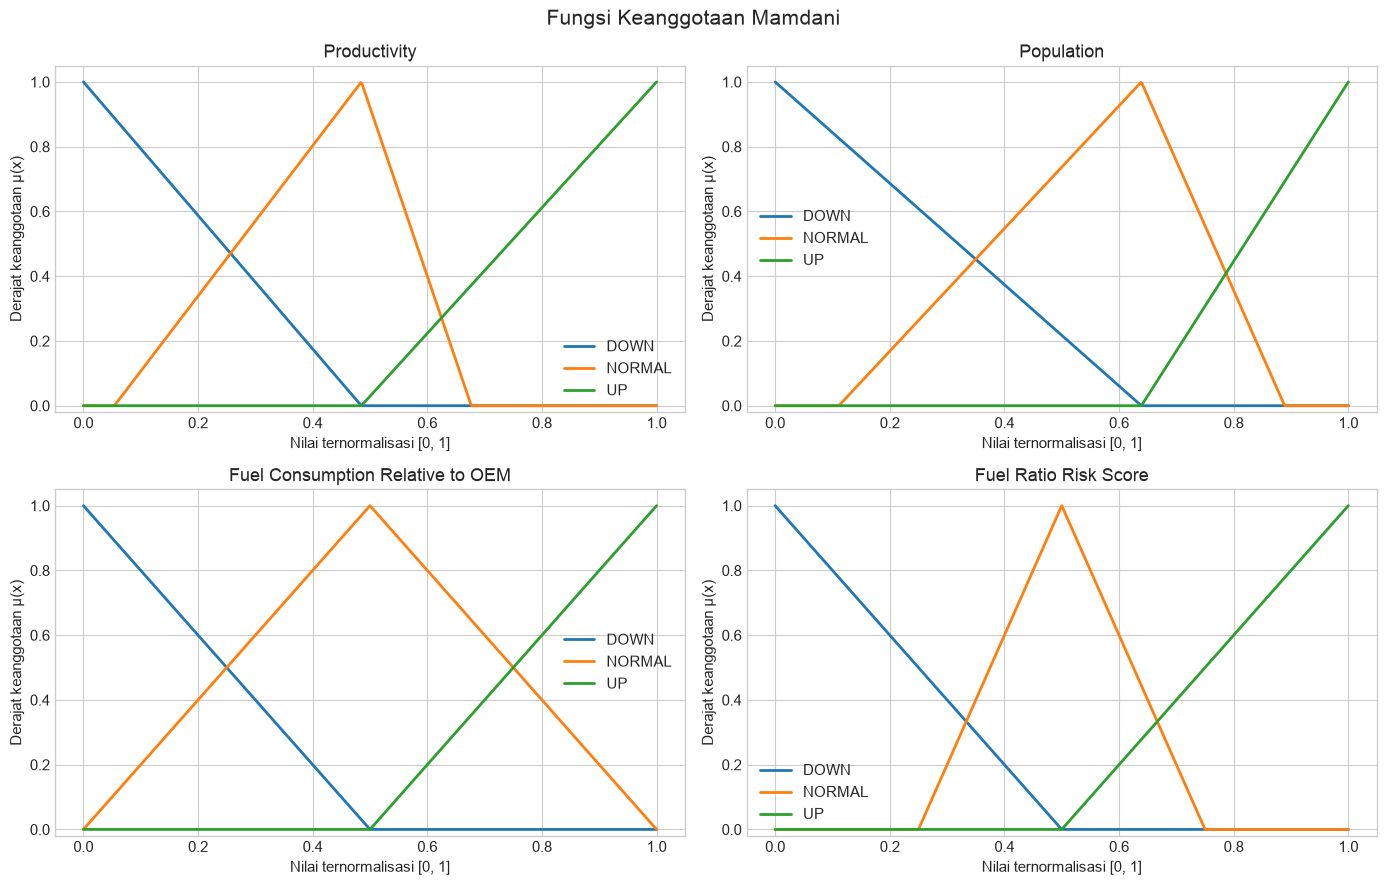

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, variable, title in [(axes[0, 0], productivity, 'Productivity'), (axes[0, 1], population, 'Population'), (axes[1, 0], fuel_consumption, 'Fuel Consumption Relative to OEM'), (axes[1, 1], fuel_ratio_score, 'Fuel Ratio Risk Score')]:
    for label, term in variable.terms.items():
        ax.plot(domain, term.mf, linewidth=2, label=label)
    ax.set_title(title)
    ax.set_xlabel('Nilai ternormalisasi [0, 1]')
    ax.set_ylabel('Derajat keanggotaan μ(x)')
    ax.set_ylim(-0.02, 1.05)
    ax.legend()
fig.suptitle('Fungsi Keanggotaan Mamdani', fontsize=15)
fig.tight_layout()
plt.show()

## 3. Rule Base Mamdani

Rule default NORMAL menjaga seluruh domain input memiliki output. Rule ini hanya menjadi baseline; rule UP/DOWN akan menggeser hasil ketika evidence cukup kuat.

In [6]:
rules = [
    ctrl.Rule(productivity['UP'], fuel_ratio_score['DOWN']),
    ctrl.Rule(population['UP'], fuel_ratio_score['UP']),
    ctrl.Rule(fuel_consumption['UP'], fuel_ratio_score['UP']),
    ctrl.Rule(productivity['DOWN'] & fuel_consumption['UP'], fuel_ratio_score['UP']),
    ctrl.Rule(productivity['UP'] & population['DOWN'] & fuel_consumption['DOWN'], fuel_ratio_score['DOWN']),
    ctrl.Rule(productivity['NORMAL'] & population['NORMAL'] & fuel_consumption['NORMAL'], fuel_ratio_score['NORMAL']),
    ctrl.Rule(productivity['UP'] & population['NORMAL'], fuel_ratio_score['DOWN']),
    ctrl.Rule(population['DOWN'] & fuel_consumption['DOWN'], fuel_ratio_score['DOWN']),
    ctrl.Rule(productivity['DOWN'] | productivity['NORMAL'] | productivity['UP'], fuel_ratio_score['NORMAL']),
]
fr_ctrl = ctrl.ControlSystem(rules)
print(f'✅ {len(rules)} rules aktif; default rule menjamin coverage input.')

✅ 9 rules aktif; default rule menjamin coverage input.


## 4. Evaluasi Unit

Kolom `fuel_ratio_actual` tidak ditimpa oleh model. Model menghasilkan `risk_score`; status `Efisien/Normal/Boros` adalah interpretasi skor tersebut, sedangkan sumber nilai aktual/estimasi ditampilkan terpisah.

In [7]:
def infer_row(row):
    sim = ctrl.ControlSystemSimulation(fr_ctrl)
    values = {
        'productivity': safe_normalize(row['productivity'], P_min, P_max),
        'population': safe_normalize(row['population'], POP_min, POP_max),
        'fuel_consumption': float(row['fuel_oem_position']),
    }
    for name, value in values.items():
        sim.input[name] = value
    sim.compute()
    result = {'risk_score': float(sim.output['fuel_ratio_score'])}
    variable_names = {'prod': 'productivity', 'pop': 'population', 'fuel': 'fuel_consumption'}
    variables = {'prod': productivity, 'pop': population, 'fuel': fuel_consumption}
    for prefix, variable in variables.items():
        for label, term in variable.terms.items():
            value = values[variable_names[prefix]]
            result[f'mu_{prefix}_{label}'] = round(float(fuzzy.interp_membership(domain, term.mf, value)), 4)
    return pd.Series(result)

df_eval = df_eq.copy()
df_eval = pd.concat([df_eval, df_eval.apply(infer_row, axis=1)], axis=1)
df_eval['evaluation'] = pd.cut(df_eval['risk_score'], [-np.inf, 0.35, 0.65, np.inf], labels=['Efisien (DOWN)', 'Normal', 'Boros (UP)'])
output_cols = ['equipment_id', 'contractor', 'unit_type', 'fuel_cons_lhr', 'fuel_ratio_actual', 'fuel_ratio_source', 'mu_prod_DOWN', 'mu_prod_NORMAL', 'mu_prod_UP', 'mu_pop_DOWN', 'mu_pop_NORMAL', 'mu_pop_UP', 'mu_fuel_DOWN', 'mu_fuel_NORMAL', 'mu_fuel_UP', 'risk_score', 'evaluation']
print(df_eval[output_cols].to_string(index=False))

 equipment_id contractor  unit_type  fuel_cons_lhr  fuel_ratio_actual  fuel_ratio_source  mu_prod_DOWN  mu_prod_NORMAL  mu_prod_UP  mu_pop_DOWN  mu_pop_NORMAL  mu_pop_UP  mu_fuel_DOWN  mu_fuel_NORMAL  mu_fuel_UP  risk_score     evaluation
            1      PT. A    EX26007         179.52               0.20 operational actual        0.0000          0.1078      0.3323       0.8261         0.0009     0.0000        0.1781          0.8219      0.0000    0.354639         Normal
            2      PT. B  PC125011R          59.00               0.19 operational actual        0.9471          0.0000      0.0000       0.0000         0.0000     0.8462        0.0000          1.0000      0.0000    0.665456     Boros (UP)
            3      PT. C  PC1250SP8          69.12               0.22 operational actual        0.9258          0.0000      0.0000       0.0435         0.9474     0.0000        0.0000          0.7774      0.2226    0.571837         Normal
            4      PT. D  PC200011R         

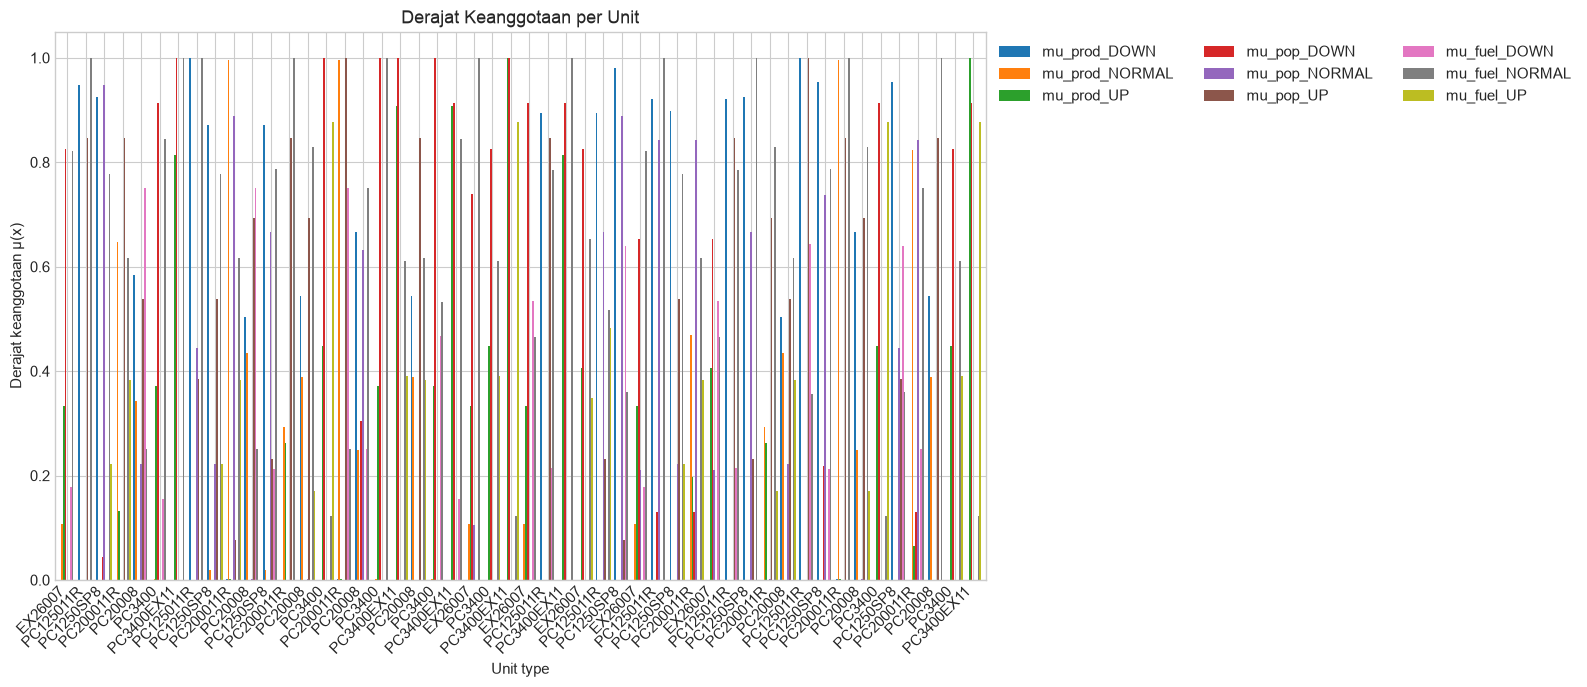

In [8]:
membership_cols = ['mu_prod_DOWN', 'mu_prod_NORMAL', 'mu_prod_UP', 'mu_pop_DOWN', 'mu_pop_NORMAL', 'mu_pop_UP', 'mu_fuel_DOWN', 'mu_fuel_NORMAL', 'mu_fuel_UP']
ax = df_eval.set_index('unit_type')[membership_cols].plot(kind='bar', figsize=(16, 7), width=0.85)
ax.set_title('Derajat Keanggotaan per Unit')
ax.set_xlabel('Unit type')
ax.set_ylabel('Derajat keanggotaan μ(x)')
ax.set_ylim(0, 1.05)
ax.legend(ncol=3, bbox_to_anchor=(1, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [9]:
# Smoke test: seluruh kombinasi grid harus menghasilkan output, tanpa fallback diam-diam.
errors = []
for p in np.linspace(0, 1, 15):
    for q in np.linspace(0, 1, 15):
        for f in np.linspace(0, 1, 5):
            try:
                sim = ctrl.ControlSystemSimulation(fr_ctrl)
                sim.input['productivity'] = p
                sim.input['population'] = q
                sim.input['fuel_consumption'] = f
                sim.compute()
                value = sim.output['fuel_ratio_score']
                if not 0.0 <= value <= 1.0:
                    errors.append((p, q, f, 'outside domain'))
            except Exception as exc:
                errors.append((p, q, f, repr(exc)))
print('✅ Smoke test passed.' if not errors else f'❌ {len(errors)} kombinasi gagal: {errors[:3]}')

✅ Smoke test passed.


## Kesimpulan

Model ini sekarang transparan: referensi OEM dipetakan per unit bila memungkinkan, fallback diberi label, transaksi aktual diprioritaskan, dan output fuzzy tidak lagi disamarkan sebagai Fuel Ratio aktual. Untuk produksi, pemetaan unit ke `fuel_reference_id` sebaiknya disimpan eksplisit di database agar tidak bergantung pada text similarity.